# K-Means Clustering

K-Means is an **unsupervised machine learning algorithm** used to group similar data points into **K clusters**. It tries to place similar observations in the same cluster and separate dissimilar observations into different clusters.

---

# How K-Means Works

### 1. Choose the Number of Clusters (K)

Select the number of clusters into which the data should be divided.

### 2. Initialize Centroids

Randomly select K data points as the initial centroids (cluster centers).

### 3. Assign Data Points

Calculate the distance between each data point and every centroid. Assign each data point to the nearest centroid.

### 4. Update Centroids

Compute the new centroid of each cluster by taking the mean of all points assigned to that cluster. The centroid moves toward the center of its assigned points.

### 5. Repeat Assignment and Update

Reassign data points based on the updated centroids and recalculate the centroids again. Repeat this process until the clusters stabilize.

### 6. Stop When Convergence is Reached

When the centroids no longer change significantly, the algorithm has converged and the final clusters are obtained.

---

# Advantages of K-Means

1. Simple and easy to understand.
2. Fast and computationally efficient.
3. Works well with large datasets.
4. Clusters are easy to visualize and interpret.

---

# Disadvantages of K-Means

1. The value of K (number of clusters) must be specified beforehand.
2. Sensitive to centroid initialization; different initial centroids may produce different results.
3. Sensitive to outliers, which can affect cluster quality.
4. Performs poorly on non-spherical or overlapping clusters.

---

# Important Interview Questions and Answers

## Q1. What is K-Means Clustering? Why is it called K-Means?

**Answer:**
K-Means is an unsupervised learning algorithm used to divide data into K clusters.

It is called **K-Means** because:

* **K** = Number of clusters.
* **Means** = The centroid of each cluster is calculated using the mean (average) of its data points.

---

## Q2. What is a Centroid?

**Answer:**
A centroid is the center point of a cluster. It is calculated by taking the average of all data points in that cluster.

---

## Q3. What is Convergence in K-Means?

**Answer:**
Convergence occurs when the centroids stop changing significantly and cluster assignments remain unchanged.

---

## Q4. What is the Elbow Method? How do you select the optimal value of K?

**Answer:**
The Elbow Method helps determine the optimal number of clusters.

* Run K-Means for different values of K.
* Calculate WCSS (Within-Cluster Sum of Squares).
* Plot K vs WCSS.
* Choose the K value where the graph forms an "elbow" shape.

This point is considered the optimal value of K.

---

## Q5. Why does K-Means sometimes give different results?

**Answer:**
Because centroids are initialized randomly. Different initial centroids may lead to different final clusters.

---

## Q6. What is K-Means++?

**Answer:**
K-Means++ is an improved initialization technique that selects initial centroids more carefully. It helps achieve better clustering and faster convergence.

---

## Q7. Suppose one feature ranges from 1 to 1000 and another from 1 to 10. What problem can occur?

**Answer:**
The feature with the larger range will dominate the distance calculation, leading to poor clustering results.

**Solution:** Apply feature scaling (Normalization or Standardization).

---

## Q8. What happens if K is too small?

**Answer:**
Different groups may be merged into the same cluster, resulting in under-clustering and loss of important patterns.

---

## Q9. What happens if K is too large?

**Answer:**
Data may be split into many small clusters, causing over-clustering and making interpretation difficult.

---

## Q10. Suppose your dataset contains 50 numerical and 5 categorical columns. Can you directly apply K-Means?

**Answer:**
No. K-Means works only with numerical data because it uses distance calculations. Categorical variables must be encoded before applying K-Means.

---

## Q11. In which situations would you avoid using K-Means?

**Answer:**
Avoid K-Means when:

1. Data contains many outliers.
2. Clusters are non-spherical or irregularly shaped.
3. The optimal value of K is unknown.
4. The dataset contains mainly categorical features.
5. Clusters have very different sizes or densities.

---

### Exam Definition (2–3 Marks)

**K-Means is an unsupervised machine learning algorithm that partitions data into K clusters by assigning each data point to the nearest centroid and repeatedly updating the centroids until convergence is achieved.**


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN

df=pd.read_csv('/content/covid_toy - covid_toy.csv')
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [ ]:
numerical_features=['age','fever']
categorical_features=['gender','cough','city']

In [ ]:
from sklearn import preprocessing
numerical_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())])
categorical_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder())])

preprocessing=ColumnTransformer([
        ('numerical',numerical_pipeline,numerical_features),
        ('categorical',categorical_pipeline,categorical_features)])

preprocessing

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fever']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder', OneHotEncoder())]),
                                 ['gender', 'cough', 'city'])])

In [ ]:
x=preprocessing.fit_transform(df)


In [ ]:
#apply DBscan
dbscan=DBSCAN(eps=1,min_samples=5)
cluster=dbscan.fit_predict(x)
df['cluster']=cluster

df.sample(4)

,age,gender,fever,cough,city,has_covid,cluster
1,27,Male,100.0,Mild,Delhi,Yes,0
26,19,Female,100.0,Mild,Kolkata,Yes,-1
91,38,Male,NaN,Mild,Delhi,Yes,0
74,34,Female,104.0,Strong,Delhi,No,-1


In [ ]:
df[df['cluster']==-1]
df['cluster'].value_counts()

,count
cluster,
-1,94
0,6


In [ ]:
df.groupby('cluster')[['age','fever']].mean()

,age,fever
cluster,,
-1,45.255319,100.858824
0,28.000000,100.600000


In [ ]:
pd.crosstab(df['cluster'],df['has_covid'])

has_covid,No,Yes
cluster,,
-1,54,40
0,1,5


In [ ]:
 pd.crosstab(df['cluster'],df['fever'])

fever,98.0,99.0,100.0,101.0,102.0,103.0,104.0
cluster,,,,,,,
-1,17,10,11,14,10,9,14
0,0,0,2,3,0,0,0


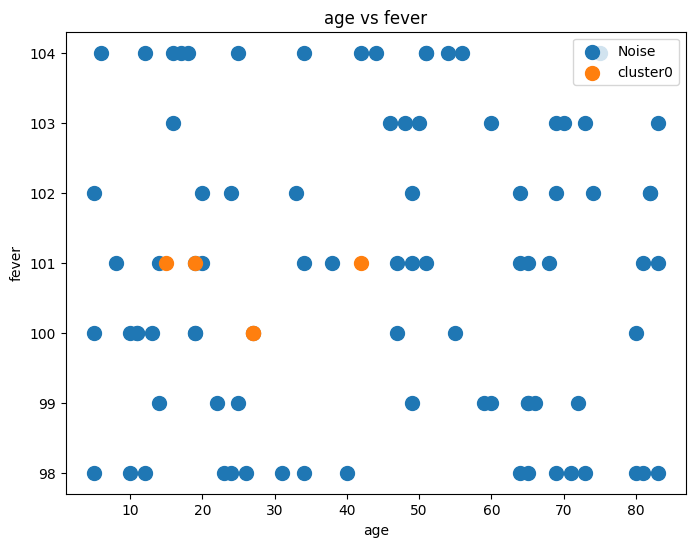

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
for i in df['cluster'].unique():
  if i==-1:
    label="Noise"
  else:
    label=f"cluster{i}"

  plt.scatter(df[df['cluster']==i]['age'],df[df['cluster']==i]['fever'],s=100,label=label)
plt.xlabel('age')
plt.ylabel('fever')
plt.title('age vs fever')
plt.legend()

In [ ]:
# practies:-

In [ ]:
from sklearn.datasets import make_moons

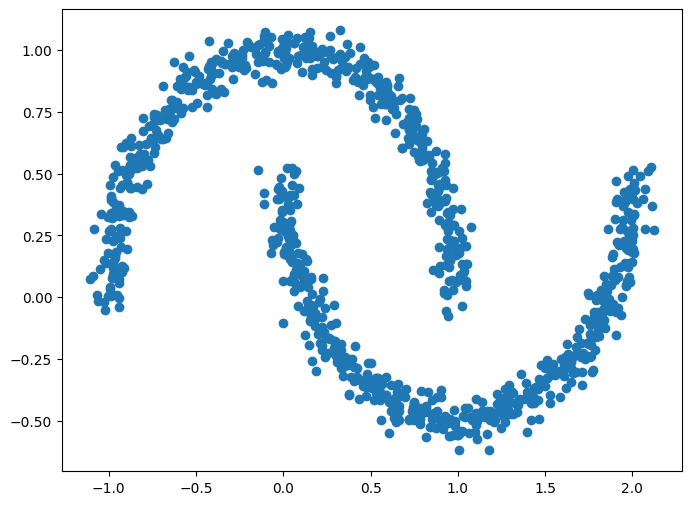

In [ ]:
x,y=make_moons(n_samples=1000,noise=0.05,random_state=42)
plt.figure(figsize=(8,6))
plt.scatter(x[:,0],x[:,1])
plt.show()

In [ ]:
import pandas as pd


In [ ]:
dbscan=DBSCAN(eps=0.2,min_samples=5)
cluster=dbscan.fit_predict(x)
pd.Series(cluster).value_counts()

,count
0,500
1,500


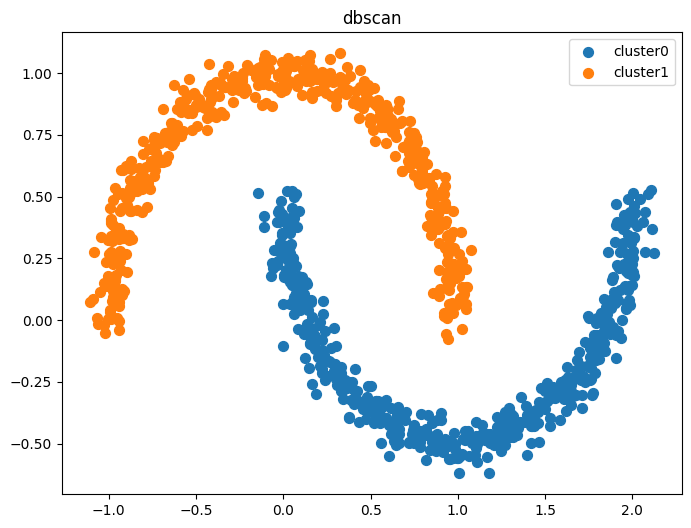

In [ ]:
plt.figure(figsize=(8,6))
for i in np.unique(cluster):
  if i==-1:
    label="Noise"
  else:
    label=f"cluster{i}"
  plt.scatter(x[cluster==i,0],x[cluster==i,1],s=50,label=label)
plt.title('dbscan')
plt.legend()
plt.show()

In [ ]:
#

In [ ]:
for eps in [0.2,0.3,0.5,0.7,1]:
  dbscan=DBSCAN(
      eps=eps,
      min_samples=5
  )

  labels=dbscan.fit_predict(x)

  print("eps =",eps)
  print(pd.Series(labels).value_counts())

eps = 0.2
0    500
1    500
Name: count, dtype: int64
eps = 0.3
0    500
1    500
Name: count, dtype: int64
eps = 0.5
0    1000
Name: count, dtype: int64
eps = 0.7
0    1000
Name: count, dtype: int64
eps = 1
0    1000
Name: count, dtype: int64
